# Imports & Downloads

In [1]:
import torch
from torch import nn
import numpy as np

import sklearn

from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from sklearn import datasets
import matplotlib.pyplot as plt

import warnings

### Simulate Data

In [2]:
%%writefile simulate_data.py
import torch
import sys
from sklearn.model_selection import train_test_split

RANDOM_SEED = 42

def generate(RANDOM_SEED):
    torch.manual_seed(RANDOM_SEED)
    n = 1000
    p1 = 50 # number of input features after PCA
    p2 = 80
    p3 = 30
    k = 2
    z = torch.normal(mean=0, std=1, size=(n, k)) # assume data is already standardized

    stdev_scaler = 0

    true_w3 = torch.randn(p1, k)
    x1 = z @ true_w3.T + stdev_scaler * torch.randn(n, p1) # x: original input data (n, p)

    true_w4 = torch.randn(p2, k)
    x2 = z @ true_w4.T + stdev_scaler * torch.randn(n, p2)

    true_w5 = torch.randn(p3, k)
    x3 = z @ true_w5.T + stdev_scaler * torch.randn(n, p3)

    # sparse version with diffferent cols set to 0
    z_sparse = z.clone()
    z_sparse[:500, 0] = 0
    z_sparse[500:, 1] = 0

    x1_sparse = z_sparse @ true_w3.T + stdev_scaler * torch.randn(n, p1)
    x2_sparse = z_sparse @ true_w4.T + stdev_scaler * torch.randn(n, p2)
    x3_sparse = z_sparse @ true_w5.T + stdev_scaler * torch.randn(n, p3)


    # implement train test split
    indices = range(len(z_sparse))
    train_indices, test_indices = train_test_split(indices, test_size=0.2, random_state=RANDOM_SEED)
    x1_train, x1_test = x1[train_indices], x1[test_indices]
    x2_train, x2_test = x2[train_indices], x2[test_indices]
    x3_train, x3_test = x3[train_indices], x3[test_indices]
    z_train, z_test = z[train_indices], z[test_indices]

    x1_sparse_train, x1_sparse_test = x1_sparse[train_indices], x1_sparse[test_indices]
    x2_sparse_train, x2_sparse_test = x2_sparse[train_indices], x2_sparse[test_indices]
    x3_sparse_train, x3_sparse_test = x3_sparse[train_indices], x3_sparse[test_indices]
    z_sparse_train, z_sparse_test = z_sparse[train_indices], z_sparse[test_indices]

    return z, z_sparse, x1, x2, x3, x1_sparse, x2_sparse, x3_sparse, z_train, z_test, z_sparse_train, z_sparse_test, x1_train, x2_train, x3_train, x1_sparse_train, x2_sparse_train, x3_sparse_train, p1, p2, p3, x1_test, x2_test, x3_test, x1_sparse_test, x2_sparse_test, x3_sparse_test

z, z_sparse, x1, x2, x3, x1_sparse, x2_sparse, x3_sparse, z_train, z_test, z_sparse_train, z_sparse_test, x1_train, x2_train, x3_train, x1_sparse_train, x2_sparse_train, x3_sparse_train, p1, p2, p3, x1_test, x2_test, x3_test, x1_sparse_test, x2_sparse_test, x3_sparse_test = generate(RANDOM_SEED)

Overwriting simulate_data.py


In [3]:
%run simulate_data.py

In [4]:
RANDOM_SEED

42

In [5]:
import torch
import matplotlib.pyplot as plt

# ----- Correlation Function -----
def columnwise_correlation(A, B):
    A_centered = A - A.mean(dim=0)
    B_centered = B - B.mean(dim=0)

    A_std = A_centered.std(dim=0, unbiased=False)
    B_std = B_centered.std(dim=0, unbiased=False)

    cov = A_centered.T @ B_centered / A.shape[0]
    corr = cov / (A_std[:, None] * B_std[None, :])

    return corr


# ----- Compute Correlations -----
corr_x1 = columnwise_correlation(z_sparse, x1_sparse)
corr_x2 = columnwise_correlation(z_sparse, x2_sparse)
corr_x3 = columnwise_correlation(z_sparse, x3_sparse)

# ----- Print Summary Stats -----
print("Max abs corr with x1:", float(corr_x1.abs().max()))
print("Max abs corr with x2:", float(corr_x2.abs().max()))
print("Max abs corr with x3:", float(corr_x3.abs().max()))

corr_x1

Max abs corr with x1: 0.9999955296516418
Max abs corr with x2: 0.9999827742576599
Max abs corr with x3: 0.9998224377632141


tensor([[-0.9641, -0.8436,  0.4242, -0.5313,  0.1918, -0.8948,  0.9289,  0.9419,
         -0.7541,  0.8299, -0.7118,  0.9594, -1.0000,  0.3428, -0.8359, -0.9175,
         -0.7838,  0.9633, -0.7810, -0.5295, -0.2501,  0.7791, -0.9989, -0.9100,
         -0.9947,  0.1679, -0.9778, -0.4433, -0.7181,  0.9990,  0.8989, -0.4788,
          0.8847, -0.9572, -0.1366, -0.2230,  0.1376, -0.9392, -0.9747, -0.4161,
          0.6809, -0.5099, -0.8964,  0.2252, -0.6829,  0.4651,  0.6084, -0.9974,
          0.3622, -0.3811],
        [-0.2656, -0.5369,  0.9055,  0.8472,  0.9814,  0.4466,  0.3703,  0.3359,
         -0.6567, -0.5580, -0.7024,  0.2821,  0.0030,  0.9394, -0.5488, -0.3978,
          0.6210, -0.2684, -0.6245,  0.8484,  0.9682,  0.6268, -0.0473, -0.4145,
         -0.1027,  0.9858, -0.2096, -0.8963, -0.6959,  0.0448,  0.4381,  0.8780,
          0.4662, -0.2894, -0.9906,  0.9748, -0.9905, -0.3434, -0.2234, -0.9093,
         -0.7324, -0.8602, -0.4431, -0.9743, -0.7305, -0.8853,  0.7936,  0.0722,


(array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]),
 array([-7.91749668, -7.58814669, -7.25879669, -6.92944717, -6.60009718,
        -6.27074718, -5.94139719, -5.6120472 , -5.28269768, -4.95334721,
        -4.62399769, -4.29464769, -3.9652977 , -3.6359477 , -3.30659819,
        -2.97724819, -2.6478982 , -2.3185482 , -1.98919821, -1.65984869,
        -1.3304987 , -1.0011487 , -0.67179871, -0.34244871, -0.01309872,
         0.3162508 ,  0.64560127,  0.97495079,  1.30430031,  1.63365078,
         1.9630003 ,  2.29235077,  2.62170029,  2.9510498 ,  3.28040028,
         3.60974979,  3.93910027,  4.26844978,  4.5977993 ,  4.92714977,
         5.25649929,  5.58584976,  5.91519928,  6.2445488 ,  6.57389927,
         6.90324879,  7.23259926,  7.56194878,  7.89129925,  8.22064877,
         8.54999733])

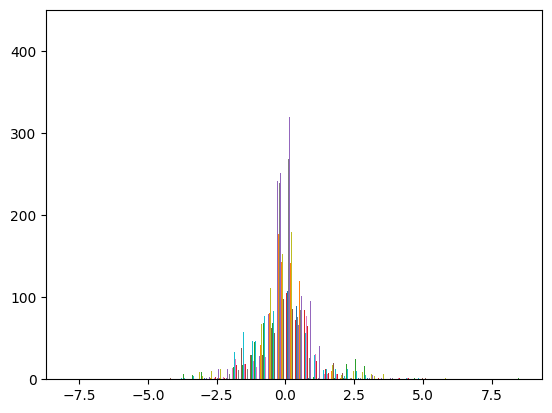

In [6]:
plt.figure()
plt.hist(x1_sparse_train.numpy(), bins=50)

In [7]:
%%writefile smbpls_model.py
import torch
import torch.nn as nn
import torch.nn.functional as F
from typing import Dict, List, Optional


def soft_threshold(x: torch.Tensor, lam: float) -> torch.Tensor:
    """Elementwise soft-thresholding: sign(x)*max(|x|-lam,0)."""
    if lam <= 0:
        return x
    return torch.sign(x) * torch.clamp(torch.abs(x) - lam, min=0.0)


class SMBPLSNet(nn.Module):
    """
    Sparse Multi-Block PLS-style REGRESSION network.

    Core structure:
      - multiple input blocks X^(b)
      - block-specific loadings W^(b)
      - block scores t^(b) = X^(b) W^(b)
      - weighted sum of block scores
      - optional sparsity on weights and scores
      - linear regression on latent components

    Output:
      - single continuous variable (or multiple if output_dim > 1)
    """

    def __init__(
        self,
        block_dims: Dict[str, int],
        n_components: int = 2,
        output_dim: int = 1, # Added this parameter
        block_weights: Optional[Dict[str, float]] = None,
        lam_w: float = 0.05,
        lam_t: float = 0.0,
        normalize_loadings: bool = True,
        eps: float = 1e-8,
    ):
        super().__init__()

        self.block_names: List[str] = list(block_dims.keys())
        self.block_dims = block_dims
        self.K = n_components # Number of PLS components
        self.output_dim = output_dim # Store it
        self.lam_w = float(lam_w)
        self.lam_t = float(lam_t)
        self.normalize_loadings = normalize_loadings
        self.eps = eps

        # block weights α_b
        if block_weights is None:
            w = 1.0 / max(len(self.block_names), 1)
            self.alpha = {b: w for b in self.block_names}
        else:
            self.alpha = {b: float(block_weights.get(b, 0.0)) for b in self.block_names}

        # block projections: (n, p_b) → (n, K)
        self.proj = nn.ModuleDict({
            b: nn.Linear(block_dims[b], self.K, bias=False)
            for b in self.block_names
        })

        # regression head: (n, K) → (n, output_dim)
        self.regressor = nn.Linear(self.K, self.output_dim, bias=True) # Changed 1 to self.output_dim

        # initialization
        for b in self.block_names:
            nn.init.normal_(self.proj[b].weight, mean=0.0, std=0.02)

        nn.init.zeros_(self.regressor.bias)

    @torch.no_grad()
    def apply_weight_sparsity_and_normalize(self) -> None:
        """
        Proximal step:
          - soft-threshold variable loadings
          - L2-normalize each component within each block
        """
        for b in self.block_names:
            W = self.proj[b].weight  # (K, p_b)

            # sparsity
            W.copy_(soft_threshold(W, self.lam_w))

    def forward(self, X_blocks):
        t = None

        for b in self.block_names:
            tb = self.proj[b](X_blocks[b])
            ab = self.alpha[b]
            t = tb * ab if t is None else t + tb * ab

        # optional sparsity ONLY — no normalization
        if self.lam_t > 0:
            t = soft_threshold(t, self.lam_t)

        y_hat = self.regressor(t)

        if self.output_dim == 1:
          y_hat = y_hat.squeeze(-1)

        return y_hat, t


    def predict(self, X_blocks: Dict[str, torch.Tensor]) -> torch.Tensor:
        """Alias for forward()."""
        return self.forward(X_blocks)
def covariance_loss(T: torch.Tensor, y: torch.Tensor, eps=1e-8):
    """
    Correct PLS2 covariance loss

    T: (n, K)
    y: (n, D)
    """
    # center
    T = T - T.mean(dim=0, keepdim=True)
    y = y - y.mean(dim=0, keepdim=True)

    n = T.shape[0]

    # covariance matrix (K × D)
    cov = (T.T @ y) / (n - 1 + eps)

    # maximize covariance
    return -(cov ** 2).sum()
def r2_score_torch(y_hat, y, eps=1e-8): # r^2 coefficient
    ss_res = torch.sum((y - y_hat) ** 2, dim=0)
    ss_tot = torch.sum((y - torch.mean(y, dim=0)) ** 2, dim=0)
    return 1 - ss_res / (ss_tot + eps)

Overwriting smbpls_model.py


In [8]:
%run smbpls_model.py

<Figure size 640x480 with 0 Axes>

In [9]:
%%writefile train_smbpls.py
import torch
import torch.nn as nn
import torch.nn.functional as F
from smbpls_model import soft_threshold, SMBPLSNet, covariance_loss, r2_score_torch
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import sys

def train_smbpls(
    RANDOM_SEED,
    z_sparse,
    z_sparse_train,
    x1_train, x2_train, x3_train,
    x1_sparse_train, x2_sparse_train, x3_sparse_train,
    z_sparse_test, x1_sparse_test, x2_sparse_test, x3_sparse_test,
    p1, p2, p3,
    n_iterations=50,
    lr=1e-3,
    show_plots=True,
):
    # Example usage with sparse 2-dimensional output data

    torch.manual_seed(RANDOM_SEED)

    # Determine output_dim from the target 'y' (z_sparse) that is used below.
    # In the global scope, `z_sparse` has shape (1000, 2), so output_dim should be 2.
    actual_output_dim = z_sparse.shape[1]

    model = SMBPLSNet(
        block_dims={"rna": p1, "atac": p2, 'prot': p3},
        n_components=2,
        output_dim=actual_output_dim,  # Pass the determined output_dim
        lam_w=0.05,
        lam_t=0.0,
    )

    # The local 'n' = 64 is not used for defining X and y in this block,
    # as they are taken from the global scope where n=1000.
    n_local = 64

    X = {
        "rna": x1_train,
        "atac": x2_train,
        'prot': x3_train
    }

    X_sparse = {
        "rna": x1_sparse_train,
        "atac": x2_sparse_train,
        'prot': x3_sparse_train
    }

    y = z_sparse_train  # continuous target, shape (1000, 2)

    Xte = {"rna": x1_sparse_test, "atac": x2_sparse_test, "prot": x3_sparse_test}
    yte = z_sparse_test


    opt = torch.optim.Adam(model.parameters(), lr=lr)

    mse_values = []
    r2_values = []

    for step in range(500):
        model.train()
        opt.zero_grad()

        y_hat, T = model(X_sparse)

        loss_pred = F.mse_loss(y_hat, y)

        loss_cov = covariance_loss(T, y)  # include covariance term

        loss = 0.5 * loss_pred + loss_cov

        loss.backward()
        opt.step()

        mse_values.append(float(loss_pred))  # store mse values at each step
        r2_values.append(float(r2_score_torch(y_hat, y).mean()))  # store r^2 correlation coefficient at each step

        if step % n_iterations == 0:
            model.apply_weight_sparsity_and_normalize()

        if step % 30 == 0:
            model.eval()
            with torch.no_grad():
                yhat, _ = model(Xte)
                print(f"At step {step} | Train MSE = {float(loss_pred)} | Test MSE = {float(F.mse_loss(yhat, yte))}")

    print("final loss:", float(loss))
    y_hat, t_loadings = model(X_sparse)
    y_hat = soft_threshold(y_hat, model.lam_w) # enforce final soft thresholding on outputs

    # plot predicted vs. true values by output dimension
    if show_plots:
      for i in range(y.shape[1]):
          plt.figure()
          plt.scatter(y_hat.detach()[:, i], y[:, i])
          plt.plot(y[:, i], y[:, i], c='r')
          plt.xlabel("Predicted")
          plt.ylabel("True")
          plt.title(f"Predicted vs True (Output Dimension {i})")
          plt.show()
    return model, mse_values, r2_values, y_hat.detach(), y

Overwriting train_smbpls.py


In [10]:
%run train_smbpls.py

/content/train_smbpls.py:79: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  mse_values.append(float(loss_pred))  # store mse values at each step


At step 0 | Train MSE = 0.45469650626182556 | Test MSE = 0.45426100492477417
At step 30 | Train MSE = 0.2659400701522827 | Test MSE = 0.2488006204366684
At step 60 | Train MSE = 0.23560525476932526 | Test MSE = 0.21103782951831818
At step 90 | Train MSE = 0.44880038499832153 | Test MSE = 0.40765148401260376
At step 120 | Train MSE = 0.24057762324810028 | Test MSE = 0.22146525979042053
At step 150 | Train MSE = 0.8308293223381042 | Test MSE = 0.27733084559440613
At step 180 | Train MSE = 0.6755483150482178 | Test MSE = 0.6108222007751465
At step 210 | Train MSE = 0.5858418345451355 | Test MSE = 0.5460962057113647
At step 240 | Train MSE = 0.9355586171150208 | Test MSE = 0.8331227898597717
At step 270 | Train MSE = 0.48006048798561096 | Test MSE = 0.43779876828193665
At step 300 | Train MSE = 0.3759032189846039 | Test MSE = 0.17241571843624115
At step 330 | Train MSE = 0.1427246332168579 | Test MSE = 0.1337762475013733
At step 360 | Train MSE = 0.05569741874933243 | Test MSE = 0.05123037

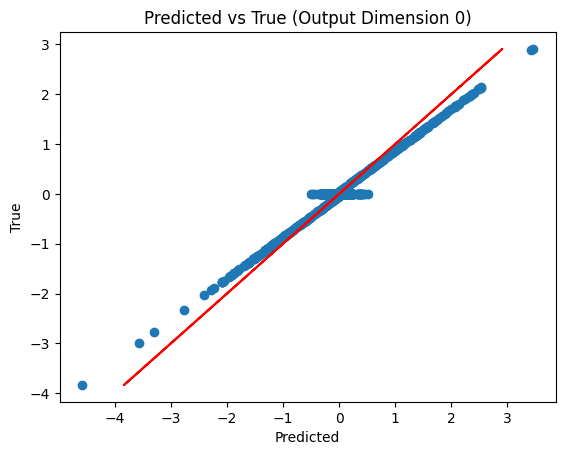

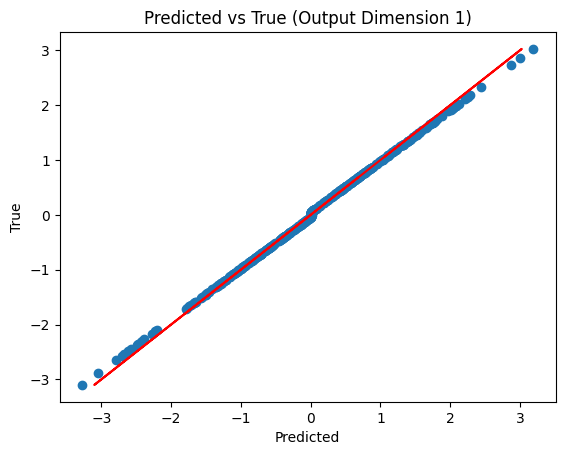

Final MSE: 0.013016587123274803


In [11]:
from train_smbpls import train_smbpls

if __name__ == "__main__":

    # Example usage with sparse 2-dimensional output data

    torch.manual_seed(RANDOM_SEED)

    model, mse_values, r2_values, y_hat, y = train_smbpls(
        RANDOM_SEED=RANDOM_SEED,
        z_sparse=z_sparse,
        z_sparse_train=z_sparse_train,
        x1_train=x1_train,
        x2_train=x2_train,
        x3_train=x3_train,
        x1_sparse_train=x1_sparse_train,
        x2_sparse_train=x2_sparse_train,
        x3_sparse_train=x3_sparse_train,
        z_sparse_test=z_sparse_test,
        x1_sparse_test=x1_sparse_test,
        x2_sparse_test=x2_sparse_test,
        x3_sparse_test=x3_sparse_test,
        p1=p1,
        p2=p2,
        p3=p3,
        show_plots=True
    )
    final_mse = float(F.mse_loss(y_hat, y))
    print("Final MSE:", final_mse)

In [12]:
first_component_pred = (y_hat[:, 0] != 0).int()
first_component_true = (y[:, 0] != 0).int()

tp = ((first_component_pred == 1) & (first_component_true == 1)).sum()
tn = ((first_component_pred == 0) & (first_component_true == 0)).sum()
fp = ((first_component_pred == 1) & (first_component_true == 0)).sum()
fn = ((first_component_pred == 0) & (first_component_true == 1)).sum()

confusion_matrix = torch.tensor([[tn, fp],
                                 [fn, tp]])

total = sum(sum(row) for row in confusion_matrix)


print(confusion_matrix / total)

print('Precision: ', tp / (tp + fp))
print('Recall: ', tp / (tp + fn))
print('Accuracy: ', (tp + tn) / total)

tensor([[0.1037, 0.4013],
        [0.0188, 0.4762]])
Precision:  tensor(0.5427)
Recall:  tensor(0.9621)
Accuracy:  tensor(0.5800)


In [13]:
second_component_pred = (y_hat[:, 1] != 0).int()
second_component_true = (y[:, 1] != 0).int()

tp = ((second_component_pred == 1) & (second_component_true == 1)).sum()
tn = ((second_component_pred == 0) & (second_component_true == 0)).sum()
fp = ((second_component_pred == 1) & (second_component_true == 0)).sum()
fn = ((second_component_pred == 0) & (second_component_true == 1)).sum()

confusion_matrix = torch.tensor([[tn, fp],
                                 [fn, tp]])

total = sum(sum(row) for row in confusion_matrix)


print(confusion_matrix / total)

print('Precision: ', tp / (tp + fp))
print('Recall: ', tp / (tp + fn))
print('Accuracy: ', (tp + tn) / total)

tensor([[0.4900, 0.0050],
        [0.0237, 0.4812]])
Precision:  tensor(0.9897)
Recall:  tensor(0.9530)
Accuracy:  tensor(0.9712)


### TODO:

1. Performance metrics vs. MSE error (DONE)
2. Epochs vs. Accuracy (DONE)
3. Correlation coefficient for different hyperparameter values
4. Change standard deviation of noise (DONE)
5. Potentially add final soft thresholding step to prediction (DONE)



MSE and $R^2$ during training epochs

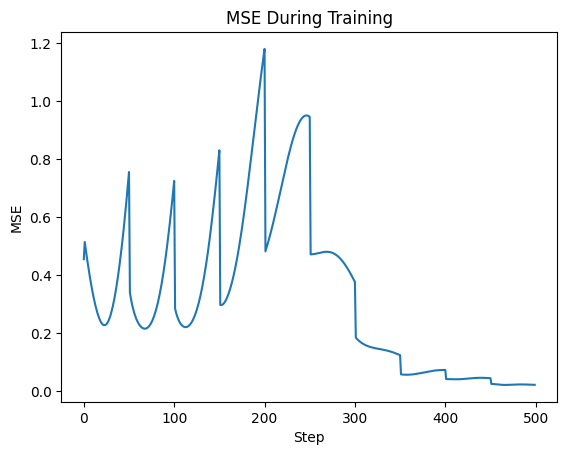

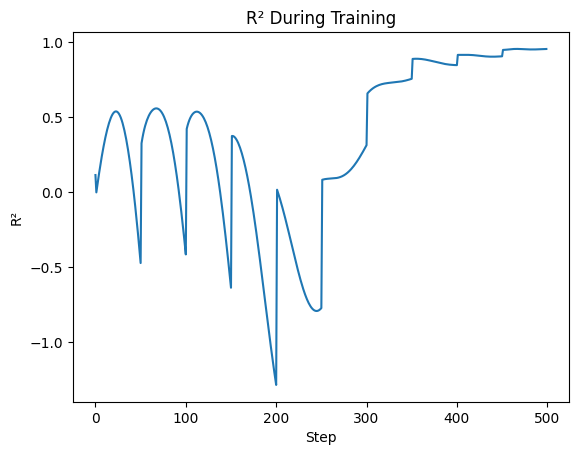

In [14]:
plt.figure()
plt.plot(mse_values)
plt.title("MSE During Training")
plt.xlabel("Step")
plt.ylabel("MSE")
plt.show()

plt.figure()
plt.plot(r2_values)
plt.title("R² During Training")
plt.xlabel("Step")
plt.ylabel("R²")
plt.show()


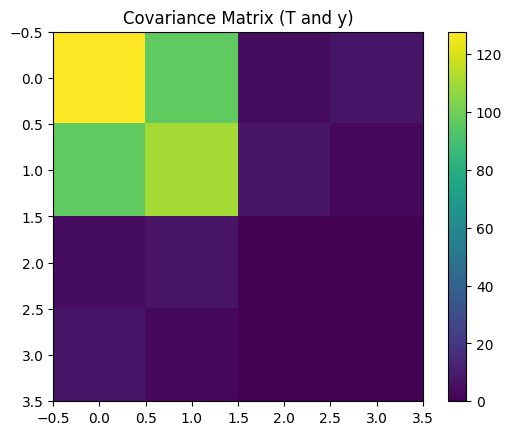

In [16]:
X_sparse = {
        "rna": x1_sparse_train,
        "atac": x2_sparse_train,
        'prot': x3_sparse_train
    }
_, T = model(X_sparse)
cov_matrix = torch.cov(torch.cat([T, y], dim=1).T)
plt.imshow(cov_matrix.detach())
plt.title("Covariance Matrix (T and y)")
plt.colorbar()
plt.show()

In [17]:
T[:15]

tensor([[  8.6147,   3.4942],
        [-15.6982, -25.1829],
        [ 17.7877,  28.5348],
        [  8.8576,  14.2094],
        [  2.9619,   4.7514],
        [ -7.0063, -11.2394],
        [-10.7552,  -4.3624],
        [  0.8347,   1.3390],
        [-28.9664, -11.7491],
        [  3.6069,   5.7862],
        [-14.4068,  -5.8436],
        [ 12.5074,   5.0731],
        [-15.5230, -24.9018],
        [  7.4291,  11.9177],
        [ -8.8472, -14.1926]], grad_fn=<SliceBackward0>)

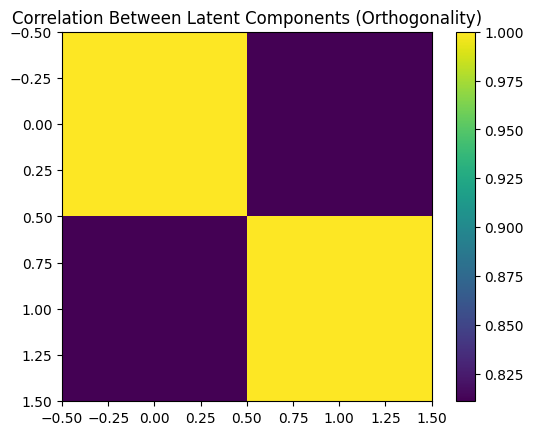

In [18]:
T_norm = T - T.mean(0)
corr = torch.corrcoef(T_norm.T)

plt.imshow(corr.detach())
plt.title("Correlation Between Latent Components (Orthogonality)")
plt.colorbar()
plt.show()

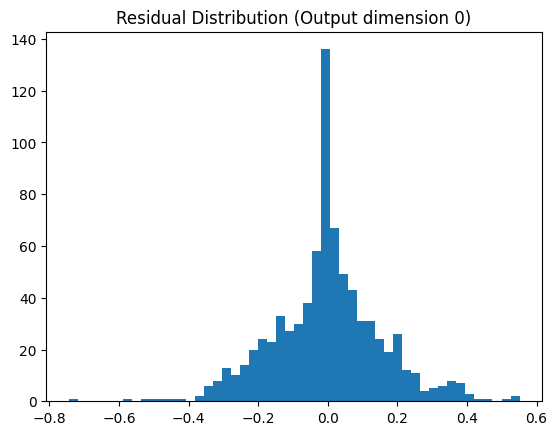

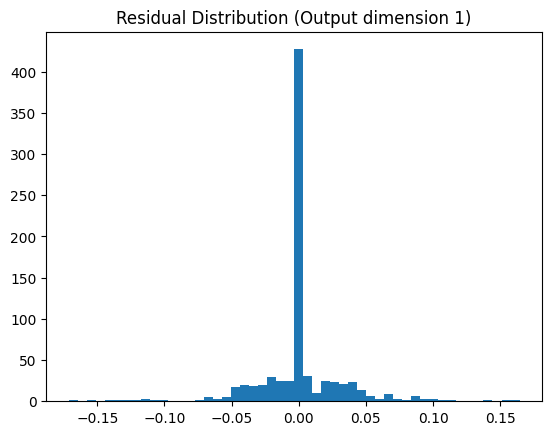

In [19]:
# check residuals are centered and Gaussian-like
residuals = (y_hat - y)

for i in range(residuals.shape[1]):
  plt.figure()
  plt.hist(residuals[:, i].numpy(), bins=50)
  plt.title(f"Residual Distribution (Output dimension {i})")
  plt.show()

## Testing Phase

In [20]:
X_sparse_test = {
        "rna": x1_sparse_test,
        "atac": x2_sparse_test,
        'prot': x3_sparse_test
    }
y_pred, T_pred = model.predict(X_sparse_test)
y_pred = y_pred.detach()

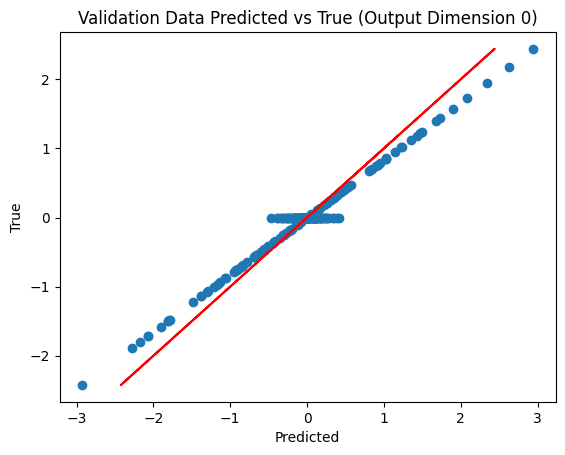

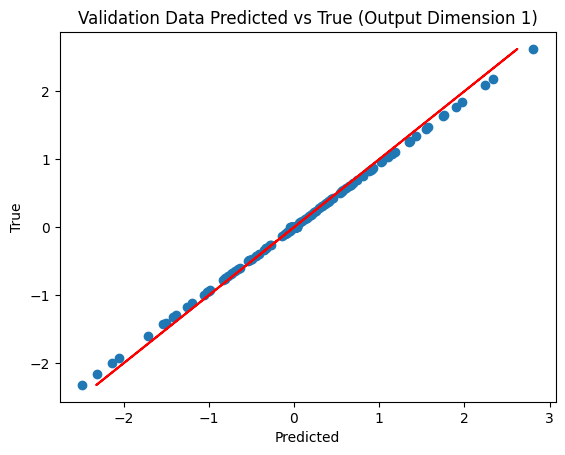

MSE on test data: 0.01830892264842987


In [21]:
# predictions on test data
y_test = z_sparse_test
for i in range(y_test.shape[1]):
        plt.figure()
        plt.scatter(y_pred[:, i], y_test[:, i])
        plt.plot(y_test[:, i], y_test[:, i], c='r')
        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.title(f"Validation Data Predicted vs True (Output Dimension {i})")
        plt.show()
mse = F.mse_loss(y_pred, y_test)
print("MSE on test data:", mse.item())

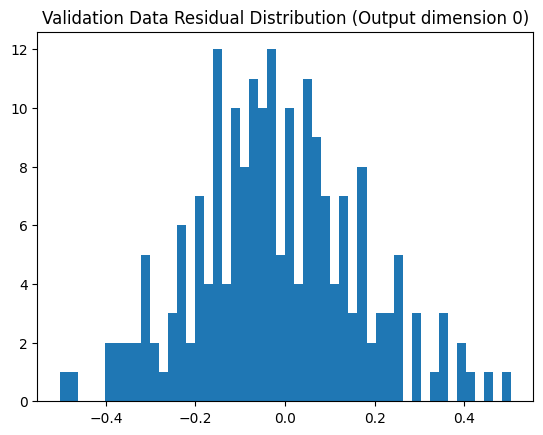

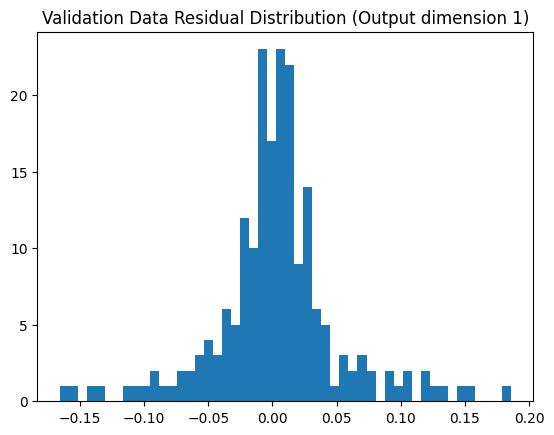

In [22]:
residuals_test = (y_pred - y_test)

for i in range(residuals_test.shape[1]):
  plt.figure()
  plt.hist(residuals_test[:, i].numpy(), bins=50)
  plt.title(f"Validation Data Residual Distribution (Output dimension {i})")
  plt.show()

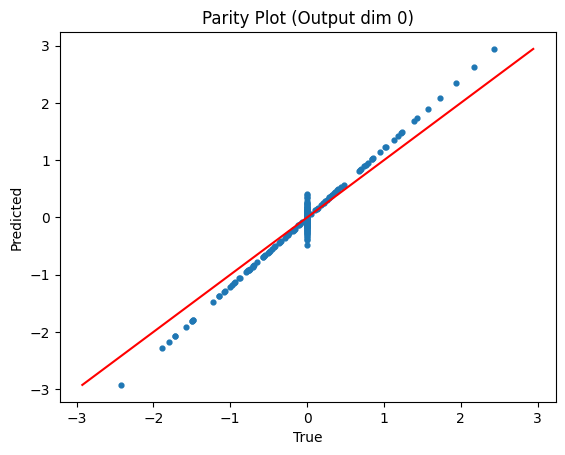

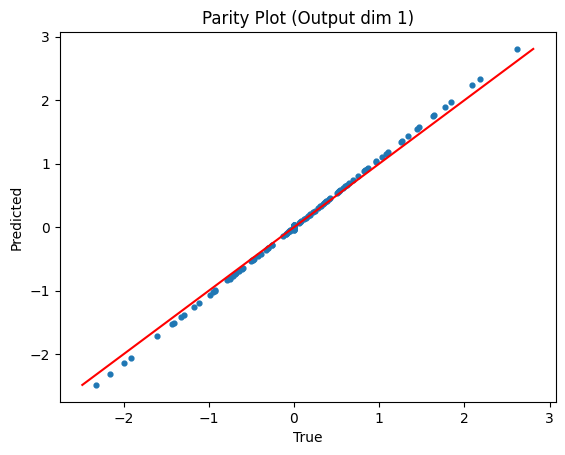

In [23]:
model.eval()
with torch.no_grad():
    Xte = {"rna": x1_sparse_test, "atac": x2_sparse_test, "prot": x3_sparse_test}
    yte = z_sparse_test
    yhat, _ = model(Xte)

yte_np = yte.detach().cpu().numpy()
yhat_np = yhat.detach().cpu().numpy()

# If output has multiple dimensions, do 1 plot per dim (or just first 2)
dims_to_plot = list(range(min(3, yte_np.shape[1])))

for d in dims_to_plot:
    plt.figure()
    plt.scatter(yte_np[:, d], yhat_np[:, d], s=12)
    mn = min(yte_np[:, d].min(), yhat_np[:, d].min())
    mx = max(yte_np[:, d].max(), yhat_np[:, d].max())
    plt.plot([mn, mx], [mn, mx], c='r')  # 45° reference line
    plt.xlabel("True")
    plt.ylabel("Predicted")
    plt.title(f"Parity Plot (Output dim {d})")
    plt.show()


In [24]:
yte_np.shape, yhat_np.shape

((200, 2), (200, 2))

- Print test MSE
## Plots to Make:
- Table for noise vs. final test MSE
- With/Without Sparsity
- With/Without Fusion (Merge datasets instead of block loadings)
- randomize `z_sparse` generation process (DONE)
- Add sparsity to true weights, compare sensitivity(non-zero vs. non-zero) and specificity(zero vs. zero) to trained weights
- print test score during training (DONE)
- Make boxplot using list of different RANDOM_SEED values (DONE)

# MSE for 50 different RANDOM_SEED values

In [25]:
from simulate_data import generate
from train_smbpls import train_smbpls
seeds = []
mses_all_seeds = []
for seed in range(50):
  z, z_sparse, x1, x2, x3, x1_sparse, x2_sparse, x3_sparse, z_train, z_test, z_sparse_train, z_sparse_test, x1_train, x2_train, x3_train, x1_sparse_train, x2_sparse_train, x3_sparse_train, p1, p2, p3, x1_test, x2_test, x3_test, x1_sparse_test, x2_sparse_test, x3_sparse_test = generate(RANDOM_SEED)
  model, mse_values, r2_values, y_hat, y = train_smbpls(
        RANDOM_SEED=seed,
        z_sparse=z_sparse,
        z_sparse_train=z_sparse_train,
        x1_train=x1_train,
        x2_train=x2_train,
        x3_train=x3_train,
        x1_sparse_train=x1_sparse_train,
        x2_sparse_train=x2_sparse_train,
        x3_sparse_train=x3_sparse_train,
        z_sparse_test=z_sparse_test,
        x1_sparse_test=x1_sparse_test,
        x2_sparse_test=x2_sparse_test,
        x3_sparse_test=x3_sparse_test,
        p1=p1,
        p2=p2,
        p3=p3,
        show_plots=False
    )
  final_mse = float(F.mse_loss(y_hat, y))
  print("Final MSE:", final_mse)
  mses_all_seeds.append(final_mse)

0 0.24989891052246094
30 -0.7452603578567505
60 -0.18016871809959412
90 -2.1474554538726807
120 -0.9734888672828674
150 -4.656124114990234
180 -3.9744789600372314
210 -4.5629682540893555
240 -13.775728225708008
270 -15.617319107055664
300 -32.311893463134766
330 -34.69333267211914
360 -37.75909423828125
390 -61.03804016113281
420 -63.89115905761719
450 -93.27029418945312
480 -95.17915344238281
final loss: -116.51282501220703
Final MSE: 0.004794907756149769
0 0.24052616953849792
30 -0.887332558631897
60 -0.26280510425567627
90 -2.556187152862549
120 -1.348774790763855
150 -5.704535961151123
180 -4.325228691101074
210 -4.124277114868164
240 -11.665973663330078
270 -12.334122657775879
300 -26.153305053710938
330 -27.45025062561035
360 -29.56006622314453
390 -49.503334045410156
420 -51.8077392578125
450 -78.02582550048828
480 -80.10165405273438
final loss: -99.76966857910156
Final MSE: 0.3607606589794159
0 0.24127493798732758
30 -0.8287098407745361
60 -0.2367209494113922
90 -2.389722347259

Text(0.5, 1.0, 'MSE values for different random seeds')

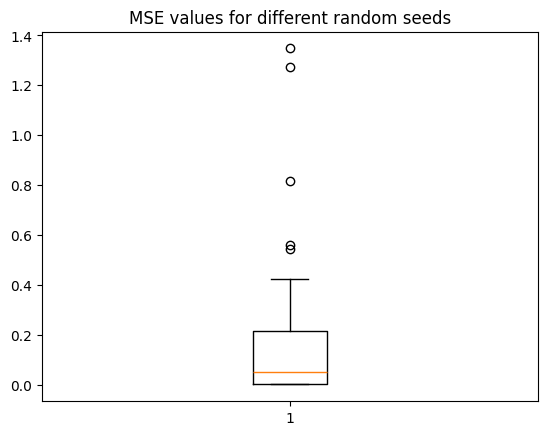

In [26]:
plt.figure()
plt.boxplot(mses_all_seeds)
plt.title("MSE values for different random seeds")